In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ASPBI Dataset

What we see that is most jobs in Region VII are from the Wholesale and retail trade sector.

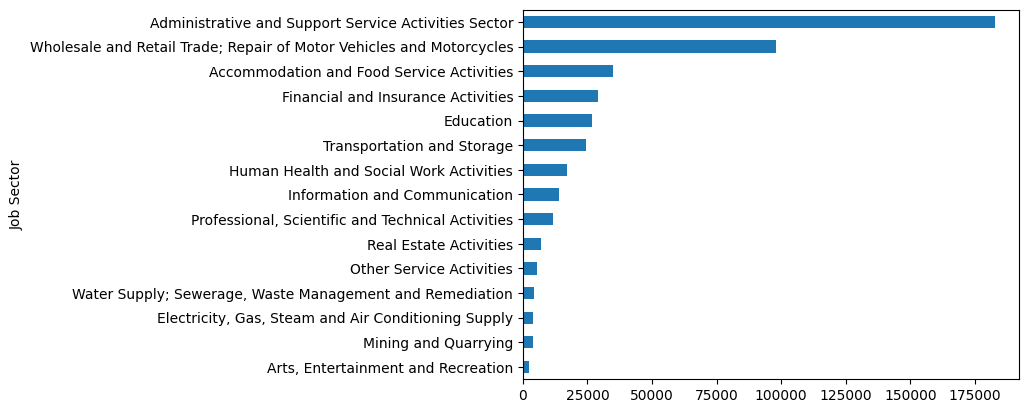

In [2]:
aggregated_df = pd.read_csv('../aspbi_data/aggregated_aspbi.csv')
aggregated_df['Total'] = pd.to_numeric(aggregated_df['Total'])
is_cebu = aggregated_df['Region Description'] == 'Region VII (Central Visayas)'
aggregated_df[is_cebu].groupby('Job Sector')['Total'].sum().sort_values(ascending=True).plot(kind='barh');

In [3]:
sectors = aggregated_df[is_cebu].groupby('Job Sector')['Total'].sum().sort_values(ascending=True)
sectors / sectors.sum()


Job Sector
Arts, Entertainment and Recreation                                      0.005139
Mining and Quarrying                                                    0.008390
Electricity, Gas, Steam and Air Conditioning Supply                     0.008743
Water Supply; Sewerage, Waste Management and Remediation                0.008820
Other Service Activities                                                0.011712
Real Estate Activities                                                  0.014686
Professional, Scientific and Technical Activities                       0.025384
Information and Communication                                           0.029941
Human Health and Social Work Activities                                 0.036657
Transportation and Storage                                              0.052076
Education                                                               0.057447
Financial and Insurance Activities                                      0.062683
Accommodation and

In [4]:
wholesale_2022 = 97914
wholesale_2021 = 95565
(wholesale_2022 - wholesale_2021) / wholesale_2021

0.02458012870820907

In [5]:
accomodation_2022 = 34928
accomodation_2021 = 32933

(accomodation_2022 - accomodation_2021) /accomodation_2021

0.06057753620988067

In [6]:
financial_2022 = 29174
financial_2021 = 24869
(financial_2022 - financial_2021) / financial_2021

0.17310708110499015

In [7]:
admin_2022 = 182863
admin_2021 =  188276 

(admin_2022 - admin_2021) / admin_2021

-0.028750345237842315

If we further check on the Administrative and Support Service Activities Sector, we see that it primarily focuses on call centers wit over 20% of all people in region VII working in just the Call centers and other related acitviites subsector.

<Axes: ylabel='Job Subsector'>

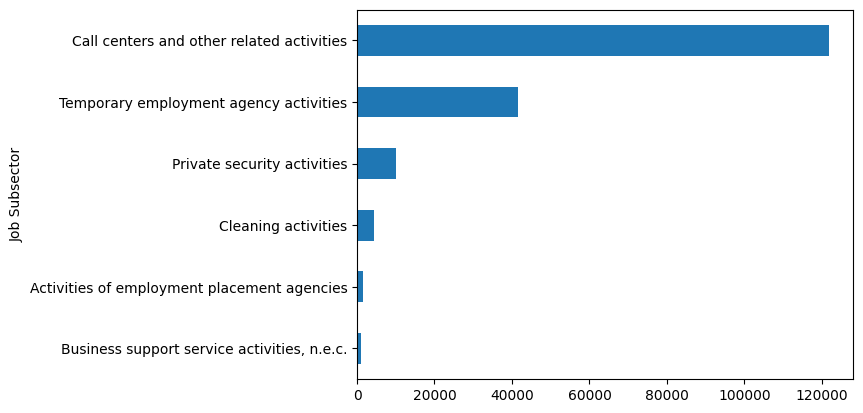

In [8]:
granular_df = pd.read_csv('../aspbi_data/granular_aspbi.csv')
is_cebu = granular_df['Region Description'] == 'Region VII (Central Visayas)'
is_admin = granular_df['Job Sector'] == 'Administrative and Support Service Activities Sector'
granular_df[is_cebu & is_admin].groupby('Job Subsector')[['Total Male', 'Total Female']].sum().sum(axis=1).sort_values(ascending=True).iloc[-6:].plot(kind='barh')

In [9]:
granular_df[is_cebu & is_admin].groupby('Job Subsector')[['Total Male', 'Total Female']].sum().sum(axis=1).sort_values(ascending=True)

Job Subsector
Security systems service activities                                                       0.0
Combined facilities support activities                                                    0.0
Investigation activities                                                                  0.0
Landscape care and maintenance service activities                                         0.0
Renting and leasing of motor vehicles                                                     0.0
Other human resources provision                                                           0.0
Renting and leasing of personal and household goods                                      52.0
Leasing of intellectual property and \nsimilar products, except copyrighted works       102.0
Other reservation service and related activities                                        125.0
Renting and leasing of other machinery, equipment and tangible goods, n.e.c.            253.0
Travel agency and tour operator activities    

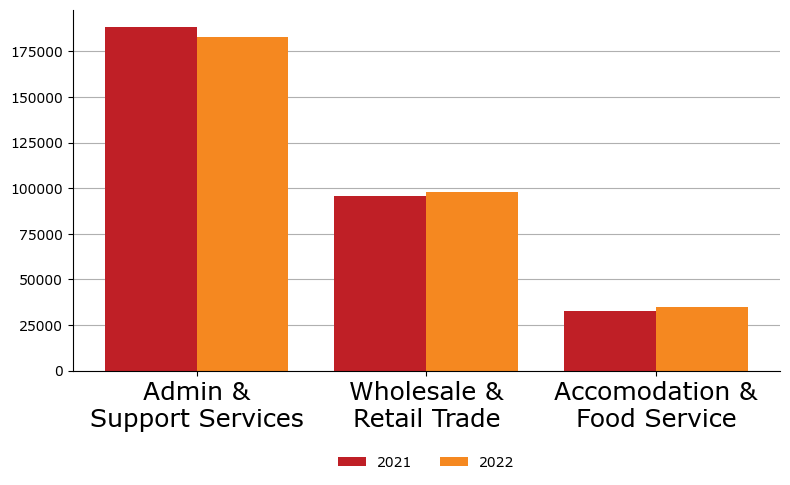

In [10]:
from matplotlib import rcParams

rcParams['font.family'] = 'Verdana'
# Data
categories = ['Admin &\nSupport Services', 'Wholesale &\nRetail Trade', 'Accomodation &\nFood Service']  # replace with actual names
year_2021 = [188276, 95565, 32933]
year_2022 = [182863, 97914, 34928]
growth = [-2.88, 2.46, 6.06]  # in %

x = range(len(categories))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
ax.bar([i - bar_width/2 for i in x], year_2021, width=bar_width, label='2021', color='#bf1f26')
ax.bar([i + bar_width/2 for i in x], year_2022, width=bar_width, label='2022', color='#f58820ff')


ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=18)
ax.set_ylabel('Values')
ax.set_title('')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False
)

ax.set_axisbelow(True)
plt.grid(True, axis='y')

plt.ylabel('')
# show graph
plt.tight_layout()
plt.savefig("../figures/visayas_sectors.png", dpi=300, bbox_inches="tight")

# show graph
plt.show()


# Training Partners for Mid-Skills

Based on the data, the following TESDA courses should be prioritized:

- Contact Center Services NC II

To identify relevant schools, we searched for each NC II course and matched them with schools offering these programs. Since the data does not specify which course each student completed, we assume that all students graduated from a TESDA course. 


In [11]:
filepath = 'data/R7 TEDSA Schools_GGIS_ with graduate count and municipality codes.csv'
partners_df = pd.read_csv(filepath)

In [12]:
partners_df.loc[partners_df['TESDA Certificate'] == 'Contact Center Services NC II', 'Graduates'].sum()

7340

In [13]:
partners_df.loc[partners_df['TESDA Certificate'] == 'Contact Center Services NC II', ['Graduates', 'Provider Name']].sort_values(by='Graduates')

,Graduates,Provider Name
119,0,"ROSEMONT HILLS MONTESSORI COLLEGE, INC."
144,30,"INTELLISENSE INSTITUTE OF TECHNOLOGY, INC."
139,61,"NORTH COAST BOHOL INSTITUTE, INC."
128,70,SBR TECHNICAL EDUCATION TRAINING CENTER INC.
127,126,SAINT HOMOBONUS ACADEMY INC.
117,176,PRIMETECH SKILLS INSTITUTE INC.
118,330,"PRIMETECH SKILLS, INSTITUTE, INC."
122,533,PHILIPPINE CALL CENTER INSTITUTE INC.
72,594,THE FOUNDATION FOR PROFESSIONAL TRAINING INC. ...
86,1730,KM100 SKILLS AND TRAINING CENTER INC.


In [14]:
partners_df[partners_df['TESDA Certificate'] == 'Customer Service NC II']

,Provider Name,Graduates,Region,Province,Municipality,Municipality Code,lat,lon,TESDA Certificate,Source
3,TREETOPZ FARM ESCAPADE DIVERSIFIED FARM,132,Region VII - Central Visayas,Bohol,Alburquerque,PH0701201,9.610419,123.956884,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...
8,BALAMBAN COMMUNITY TRAINING CENTER,36,Region VII - Central Visayas,Cebu,Balamban,PH0702208,10.504892,123.714823,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...
17,Provincial Training Center - Cebu (Carmen),334,Region VII - Central Visayas,Cebu,Carmen,PH0702215,10.608560,123.968361,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...
19,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,2009,Region VII - Central Visayas,Cebu,Cebu City (Capital),PH0702217,10.296323,123.898304,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...


In [15]:
partners_df[partners_df['TESDA Certificate'] == 'Contact Center Services NC II']

,Provider Name,Graduates,Region,Province,Municipality,Municipality Code,lat,lon,TESDA Certificate,Source
35,CEBU CALL CENTER ACADEMY,3690,Region VII - Central Visayas,Cebu,Cebu City (Capital),PH0702217,10.316720,123.890710,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1744
72,THE FOUNDATION FOR PROFESSIONAL TRAINING INC. ...,594,Region VII - Central Visayas,Cebu,Cebu City (Capital),PH0702217,10.316720,123.890710,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/Result?page=4&cur...
86,KM100 SKILLS AND TRAINING CENTER INC.,1730,Region VII - Central Visayas,Cebu,City of Bogo,PH0702211,11.048859,123.991428,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1849
117,PRIMETECH SKILLS INSTITUTE INC.,176,Region VII - Central Visayas,Cebu,Danao City,PH0702223,10.525295,123.999828,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1821
118,"PRIMETECH SKILLS, INSTITUTE, INC.",330,Region VII - Central Visayas,Cebu,Danao City,PH0702223,10.540060,123.940340,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1821
119,"ROSEMONT HILLS MONTESSORI COLLEGE, INC.",0,Region VII - Central Visayas,Cebu,Danao City,PH0702223,10.540060,123.940340,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1829
122,PHILIPPINE CALL CENTER INSTITUTE INC.,533,Region VII - Central Visayas,Bohol,Tagbilaran City,PH0701242,9.655560,123.852190,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1689
127,SAINT HOMOBONUS ACADEMY INC.,126,Region VII - Central Visayas,Cebu,Lapu-Lapu City (Opon),PH0702226,10.310280,123.949440,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1856
128,SBR TECHNICAL EDUCATION TRAINING CENTER INC.,70,Region VII - Central Visayas,Bohol,Tagbilaran City,PH0701242,9.655560,123.852190,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1696
139,"NORTH COAST BOHOL INSTITUTE, INC.",61,Region VII - Central Visayas,Bohol,Talibon,PH0701243,10.150801,124.326924,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/Result?page=5&cur...
